#### Task 2: Exploratory Data Analysis (EDA)

## Introduction

In this task, Exploratory Data Analysis (EDA) is performed on the cleaned customer sales dataset. The main objective is to understand the data, identify important patterns and trends, analyze relationships between different variables, and generate meaningful business insights using Python and Pandas.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv("cleaned_customer_sales_dataset.csv")

In [38]:
df.head()

,Customer_ID,Customer_Name,Age,Gender,City,Product,Quantity,Price,Purchase_Date,Payment_Method,Total_Amount
0,C001,Aarav,21.0,Male,Prayagraj,Laptop,1.0,45000,2026-09-01,UPI,45000.0
1,C002,Riya,23.0,female,prayagraj,Mobile Phone,2.0,25000,2026-09-01,upi,50000.0
2,C003,Aman,25.0,M,PRAYAGRAJ,Headphones,1.0,1500,2026-09-02,Credit Card,1500.0
3,C004,Neha,22.0,Female,Lucknow,Laptop,1.0,45000,2026-09-02,credit card,45000.0
4,C005,Rahul,28.0,male,lucknow,Mobile phone,1.0,25000,2026-09-03,COD,25000.0


In [39]:
text_columns = ["Customer_Name", "Gender", "City", "Product", "Payment_Method"]

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

df["Gender"] = df["Gender"].replace({
    "M": "Male",
    "male": "Male",
    "F": "Female",
    "female": "Female"
})

df["City"] = df["City"].str.title()
df["Product"] = df["Product"].str.title()

df["Payment_Method"] = df["Payment_Method"].replace({
    "upi": "UPI",
    "credit card": "Credit Card",
    "Cash on Delivery": "COD"
})

print(df["Gender"].unique())
print(df["City"].unique())
print(df["Product"].unique())
print(df["Payment_Method"].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: string
<StringArray>
['Prayagraj', 'Lucknow', 'Kanpur', 'Varanasi', 'Unknown']
Length: 5, dtype: string
<StringArray>
['Laptop', 'Mobile Phone', 'Headphones']
Length: 3, dtype: string
<StringArray>
['UPI', 'Credit Card', 'COD', 'Unknown']
Length: 4, dtype: string


In [40]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 25
Number of Columns: 11

Column Names:
['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Product', 'Quantity', 'Price', 'Purchase_Date', 'Payment_Method', 'Total_Amount']


In [41]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     25 non-null     str    
 1   Customer_Name   25 non-null     string 
 2   Age             25 non-null     float64
 3   Gender          25 non-null     string 
 4   City            25 non-null     string 
 5   Product         25 non-null     string 
 6   Quantity        25 non-null     float64
 7   Price           25 non-null     int64  
 8   Purchase_Date   25 non-null     str    
 9   Payment_Method  25 non-null     string 
 10  Total_Amount    25 non-null     float64
dtypes: float64(3), int64(1), str(2), string(5)
memory usage: 2.3 KB


In [42]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
             Age   Quantity         Price  Total_Amount
count  25.000000  25.000000     25.000000     25.000000
mean   26.980000   1.280000  25620.000000  30600.000000
std     3.828294   0.458258  17625.904232  22524.986127
min    21.000000   1.000000   1500.000000   1500.000000
25%    24.000000   1.000000   1500.000000   3000.000000
50%    26.500000   1.000000  25000.000000  25000.000000
75%    29.000000   2.000000  45000.000000  45000.000000
max    35.000000   2.000000  45000.000000  90000.000000


In [43]:
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])

print(df["Purchase_Date"].dtype)

datetime64[us]


In [44]:
print(df["Purchase_Date"].min())
print(df["Purchase_Date"].max())

2026-09-01 00:00:00
2026-09-13 00:00:00


In [45]:
product_quantity = df.groupby("Product")["Quantity"].sum()

print(product_quantity)

Product
Headphones      10.0
Laptop          10.0
Mobile Phone    12.0
Name: Quantity, dtype: float64


In [46]:
product_sales = df.groupby("Product")["Total_Amount"].sum()

print(product_sales)

Product
Headphones       15000.0
Laptop          450000.0
Mobile Phone    300000.0
Name: Total_Amount, dtype: float64


In [47]:
print("\nProduct-wise Sales:")
print(product_sales.sort_values(ascending=False))


Product-wise Sales:
Product
Laptop          450000.0
Mobile Phone    300000.0
Headphones       15000.0
Name: Total_Amount, dtype: float64


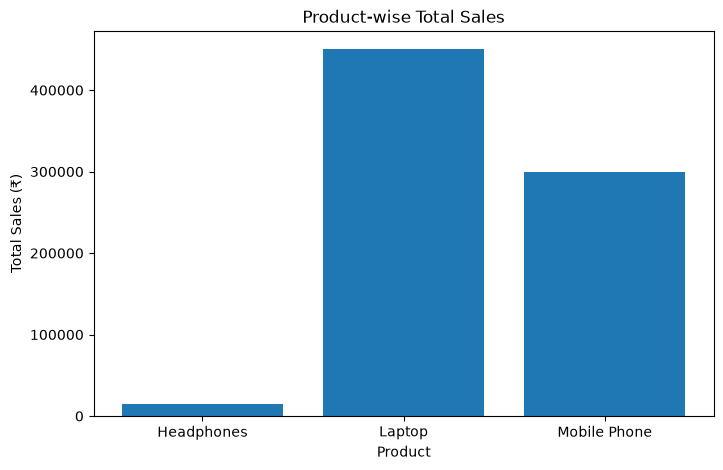

In [48]:
plt.figure(figsize=(8,5))

plt.bar(product_sales.index, product_sales.values)

plt.title("Product-wise Total Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales (₹)")

plt.show()

In [49]:
city_sales = df.groupby("City")["Total_Amount"].sum()

print(city_sales.sort_values(ascending=False))

City
Prayagraj    246000.0
Varanasi     230000.0
Lucknow      146500.0
Kanpur        97500.0
Unknown       45000.0
Name: Total_Amount, dtype: float64


In [50]:
city_quantity = df.groupby("City")["Quantity"].sum()

print(city_quantity.sort_values(ascending=False))

City
Prayagraj    12.0
Kanpur        7.0
Lucknow       6.0
Varanasi      6.0
Unknown       1.0
Name: Quantity, dtype: float64


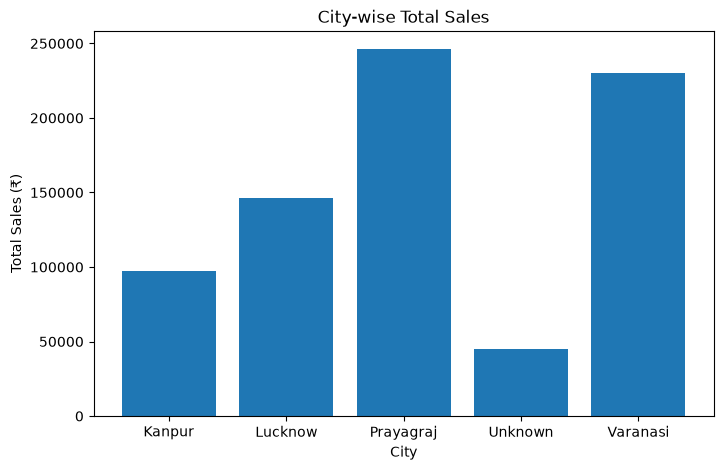

In [51]:
plt.figure(figsize=(8,5))

plt.bar(city_sales.index, city_sales.values)

plt.title("City-wise Total Sales")
plt.xlabel("City")
plt.ylabel("Total Sales (₹)")

plt.show()

In [52]:
gender_sales = df.groupby("Gender")["Total_Amount"].sum()

print(gender_sales)

Gender
Female    361000.0
Male      404000.0
Name: Total_Amount, dtype: float64


In [53]:
gender_count = df["Gender"].value_counts()

print(gender_count)

Gender
Male      13
Female    12
Name: count, dtype: Int64


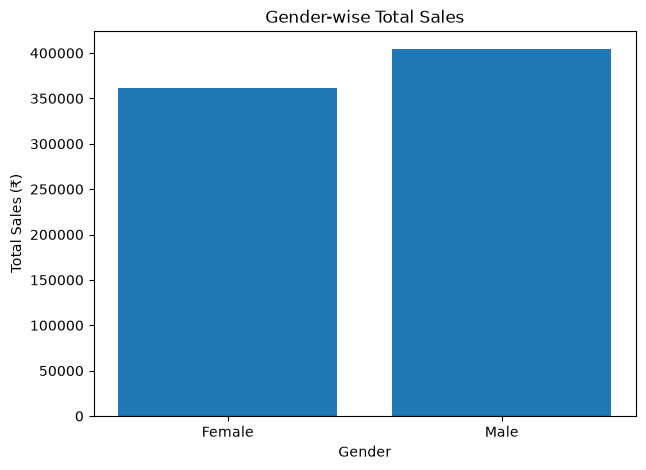

In [54]:
plt.figure(figsize=(7,5))

plt.bar(gender_sales.index, gender_sales.values)

plt.title("Gender-wise Total Sales")
plt.xlabel("Gender")
plt.ylabel("Total Sales (₹)")

plt.show()

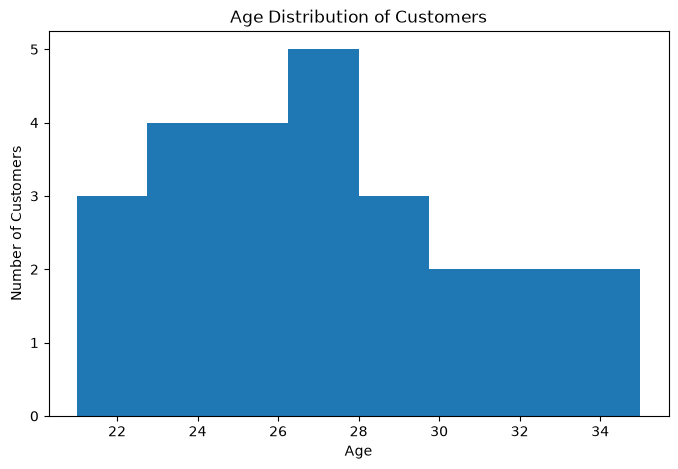

In [55]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=8)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [56]:
age_sales = df.groupby("Age")["Total_Amount"].sum()

print(age_sales)

Age
21.0     45000.0
22.0     90000.0
23.0     75000.0
24.0      4500.0
25.0      3000.0
26.0     51500.0
26.5    115000.0
27.0     28000.0
28.0     75000.0
29.0     25000.0
30.0     45000.0
31.0     90000.0
32.0     45000.0
33.0     45000.0
34.0     25000.0
35.0      3000.0
Name: Total_Amount, dtype: float64


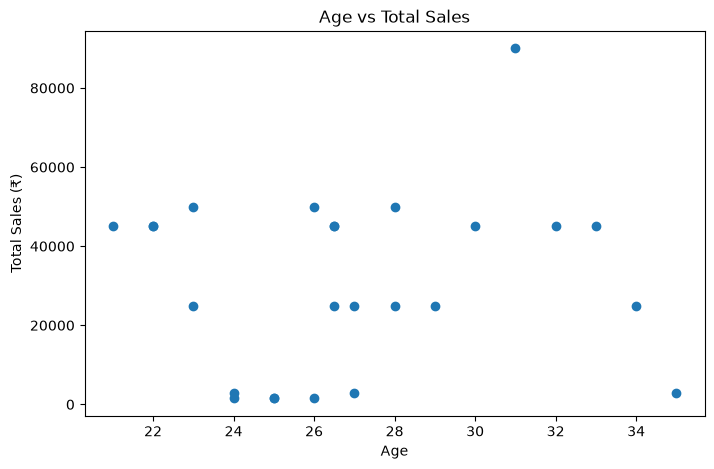

In [57]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Total_Amount"])

plt.title("Age vs Total Sales")
plt.xlabel("Age")
plt.ylabel("Total Sales (₹)")

plt.show()

In [58]:
payment_count = df["Payment_Method"].value_counts()

print(payment_count)


Payment_Method
UPI            10
Credit Card     8
COD             6
Unknown         1
Name: count, dtype: Int64


In [59]:
payment_sales = df.groupby("Payment_Method")["Total_Amount"].sum()

print(payment_sales.sort_values(ascending=False))

Payment_Method
UPI            398000.0
COD            173000.0
Credit Card    169000.0
Unknown         25000.0
Name: Total_Amount, dtype: float64


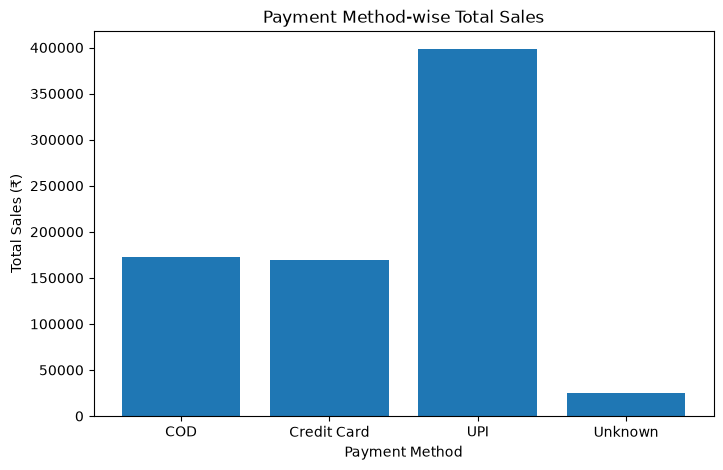

In [60]:
plt.figure(figsize=(8,5))

plt.bar(payment_sales.index, payment_sales.values)

plt.title("Payment Method-wise Total Sales")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales (₹)")

plt.show()

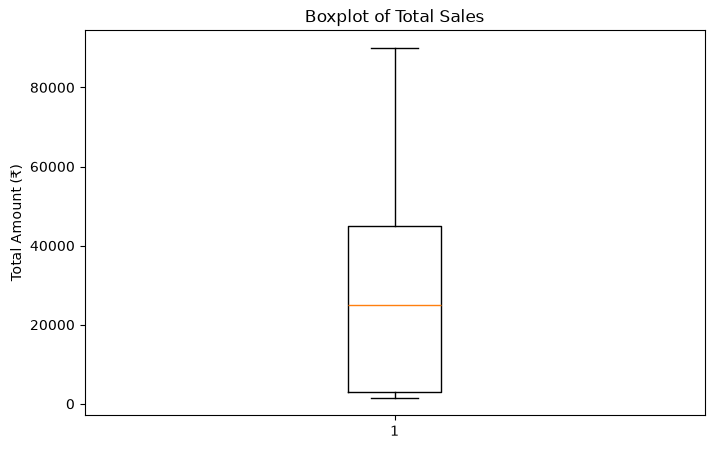

In [61]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Total_Amount"])

plt.title("Boxplot of Total Sales")
plt.ylabel("Total Amount (₹)")

plt.show()

In [62]:
Q1 = df["Total_Amount"].quantile(0.25)
Q3 = df["Total_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Total_Amount"] < lower_limit) |
    (df["Total_Amount"] > upper_limit)
]

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("\nOutliers:")
print(outliers[["Customer_ID", "Product", "Quantity", "Total_Amount"]])

Lower Limit: -60000.0
Upper Limit: 108000.0

Outliers:
Empty DataFrame
Columns: [Customer_ID, Product, Quantity, Total_Amount]
Index: []


### Insight:
The boxplot and IQR analysis show that there are no statistical outliers in the Total Amount column. All transactions fall within the calculated lower and upper limits.

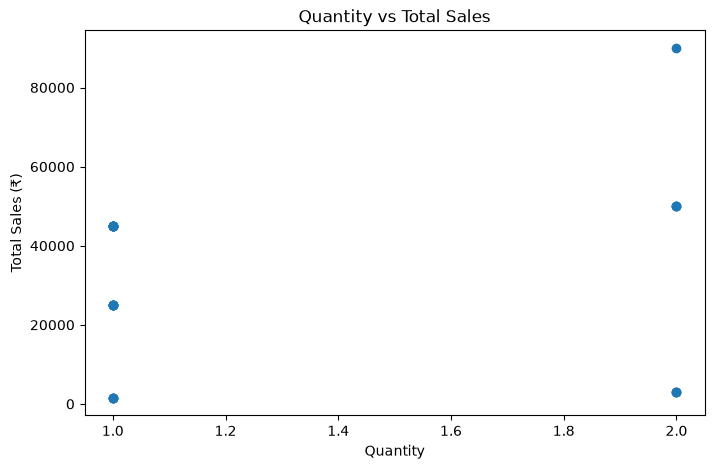

In [63]:
plt.figure(figsize=(8,5))

plt.scatter(df["Quantity"], df["Total_Amount"])

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales (₹)")

plt.show()

In [64]:
correlation = df["Quantity"].corr(df["Total_Amount"])

print("Correlation between Quantity and Total Amount:", correlation)

Correlation between Quantity and Total Amount: 0.1404733121986825


In [65]:
print("Total Sales:", df["Total_Amount"].sum())
print("Average Sales:", df["Total_Amount"].mean())
print("Maximum Sale:", df["Total_Amount"].max())
print("Minimum Sale:", df["Total_Amount"].min())
print("Total Quantity Sold:", df["Quantity"].sum())

Total Sales: 765000.0
Average Sales: 30600.0
Maximum Sale: 90000.0
Minimum Sale: 1500.0
Total Quantity Sold: 32.0


In [66]:
daily_sales = df.groupby("Purchase_Date")["Total_Amount"].sum()

print(daily_sales)

Purchase_Date
2026-09-01    95000.0
2026-09-02    46500.0
2026-09-03    28000.0
2026-09-04    70000.0
2026-09-05    91500.0
2026-09-06    70000.0
2026-09-07    28000.0
2026-09-08    70000.0
2026-09-09    48000.0
2026-09-10    70000.0
2026-09-11    51500.0
2026-09-12    46500.0
2026-09-13    50000.0
Name: Total_Amount, dtype: float64


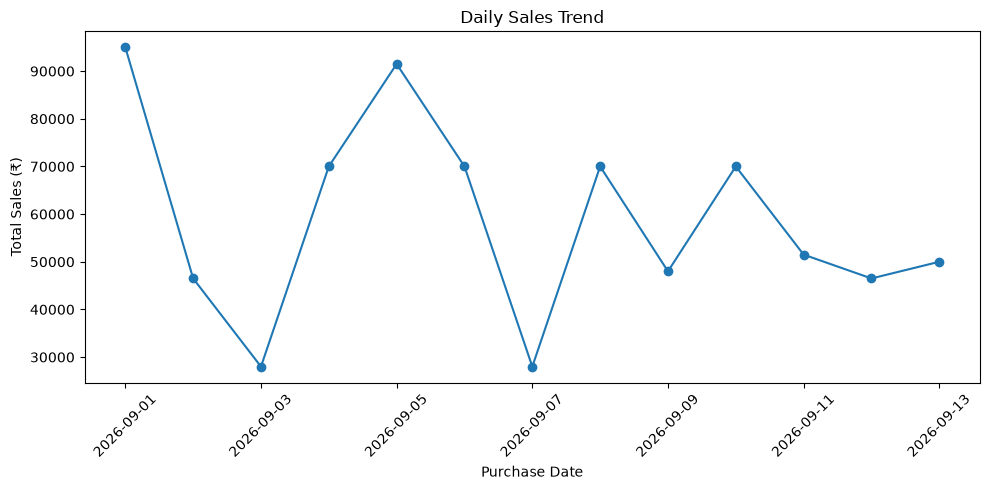

In [67]:
plt.figure(figsize=(10,5))

plt.plot(daily_sales.index, daily_sales.values, marker="o")

plt.title("Daily Sales Trend")
plt.xlabel("Purchase Date")
plt.ylabel("Total Sales (₹)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key Business Insights

1. The dataset contains 25 customer transactions with total sales of ₹7,65,000.

2. Laptop generated the highest product-wise sales of ₹4,50,000, while Mobile Phone had the highest quantity sold with 12 units.

3. Prayagraj recorded the highest city-wise sales of approximately ₹2,45,000, followed by Varanasi with approximately ₹2,30,000.

4. Male customers generated approximately ₹4,05,000 in total sales, while female customers generated approximately ₹3,60,000.

5. UPI was the most frequently used payment method with 10 transactions and generated ₹3,98,000 in sales.

6. The IQR analysis found no statistical outliers in the Total Amount column.

7. The correlation between Quantity and Total Amount was approximately 0.14, indicating a weak positive linear relationship in this dataset.

8. Daily sales showed noticeable variation during the period from September 1 to September 13, 2026.

## Conclusion

Exploratory Data Analysis was successfully performed on the cleaned customer sales dataset using Python, Pandas, and Matplotlib.

The analysis examined product-wise sales, city-wise sales, gender-wise sales, payment methods, age distribution, outliers, quantity-sales relationships, and daily sales trends.

The analysis provided useful insights into customer purchasing patterns and sales performance. The visualizations and statistical analysis helped identify important trends and relationships in the dataset.

The dataset is now ready for further visualization and dashboard development.